# <center> 基于卷积神经网络（CNN）的MNIST 手写数字识别

## 一、实验目的
1. 掌握深度学习环境配置流程，理解 Conda 虚拟环境与 Pip 包管理器的使用。
2. 掌握 Jupyter Notebook 交互式编程环境的搭建与使用，理解其在“代码分块执行”与“实时结果观察”中的优势。
3. 学习 PyTorch 的基本数据处理方式，掌握数据集加载、预处理与批量读取方法。
4. 理解卷积神经网络在图像分类任务中的基本结构与前向传播过程。
5. 完成 MNIST 手写数字识别实验，并能够对实验结果进行简单分析。

## 二、CNN 识别 MNIST 数据集手写体数字

### （一）环境配置

In [1]:
# 环境配置与导入
%matplotlib inline
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

print("环境配置完成")
print(torch.cuda.is_available())

环境配置完成
True


### （二）设置数据路径和批量大小

In [2]:
# 数据路径和超参数设置
data_root = './mnist_data/' # 尽量避免中文路径
batch_size = 64

 # 创建数据目录（如果不存在）
if not os.path.exists(data_root):
    os.makedirs(data_root)

print(f"数据存储路径: {data_root}")
print(f"批量大小: {batch_size}")

数据存储路径: ./mnist_data/
批量大小: 64


### （三）数据预处理并加载 MNIST 数据集

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root=data_root, train=True, 
                               download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, 
                              download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # 打乱样本顺序，提高训练效果
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(" MNIST 数据集加载完成")
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

 MNIST 数据集加载完成
训练集大小: 60000
测试集大小: 10000


### （四）观察训练样本

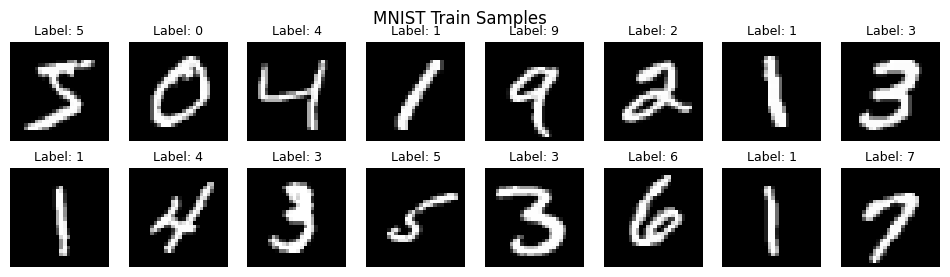

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    imgs, labels = train_dataset[i]
    ax.imshow(imgs.squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels}", fontsize=9)
    ax.axis('off')

plt.suptitle("MNIST Train Samples", fontsize=12)
plt.show()

### （五）构建卷积神经网络

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)  # 相应的改变全连接层的输入维度
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)  # 这里我多添加了一个池化层
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### （六）设置损失函数与优化器

In [6]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()  # 交叉熵损失函数
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 优化器

print("损失函数与优化器配置完成")

损失函数与优化器配置完成


### （七）训练模型

In [7]:
# 开始训练循环
epoch_times = 3
for epoch in range(epoch_times):
    print("="*15)
    print(f"第{epoch+1}个 epoch 开始训练")
    model.train()
    running_loss = 0.0
    for batch_idx, (input, labels) in enumerate(train_loader):
        input, labels = input.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(input)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 200 == 0:
            print(f"Batch {batch_idx}, Loss: {loss.item():.4f}")
        model_name = f"mnist_cnn_epoch_{epoch+1}.pth"
        checkpoint_dir = os.path.join(data_root, "checkpoint")
        if not os.path.exists(checkpoint_dir):
            os.makedirs(checkpoint_dir, exist_ok=True)
        save_path = os.path.join(checkpoint_dir, model_name)
    torch.save(model.state_dict(), save_path)
    print(f"模型权重已成功保存至数据目录 {save_path}")
print("所有 epoch 训练完成")

第1个 epoch 开始训练
Batch 0, Loss: 2.3032
Batch 200, Loss: 0.1434
Batch 400, Loss: 0.0742
Batch 600, Loss: 0.0986
Batch 800, Loss: 0.0471
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\mnist_cnn_epoch_1.pth
第2个 epoch 开始训练
Batch 0, Loss: 0.0111
Batch 200, Loss: 0.0159
Batch 400, Loss: 0.0078
Batch 600, Loss: 0.0296
Batch 800, Loss: 0.0909
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\mnist_cnn_epoch_2.pth
第3个 epoch 开始训练
Batch 0, Loss: 0.0070
Batch 200, Loss: 0.0885
Batch 400, Loss: 0.0052
Batch 600, Loss: 0.0121
Batch 800, Loss: 0.0059
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\mnist_cnn_epoch_3.pth
所有 epoch 训练完成


可以看到，经过 3 轮训练后，模型的 Loss 已经降低至 0.0059，说明模型的拟合效果较好。

### （八）在测试集上评估模型

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"测试集准确率: {100 * correct / total:.2f}%")

测试集准确率: 99.00%


模型在测试集上的准确率达到 99.00%，模型拟合效果很好。

### （九）显示预测结果

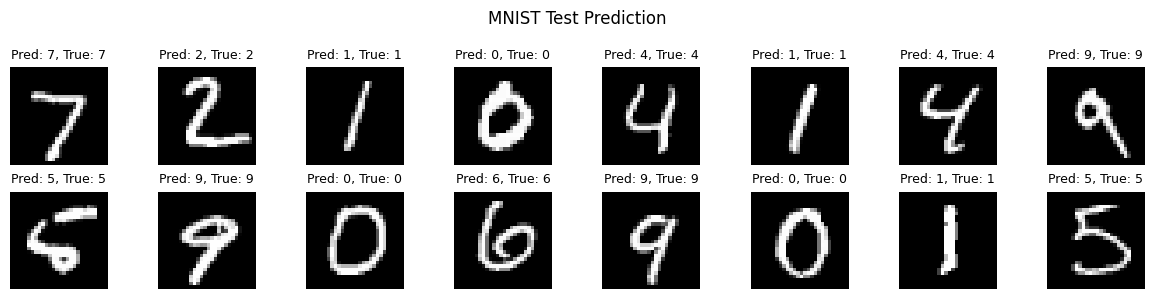

In [11]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flatten()):
    imgs, labels = test_dataset[i]
    img_input = imgs.unsqueeze(0).to(device)
    output = model(img_input)
    pred = output.argmax(1, keepdim=True).item()
    ax.imshow(imgs.squeeze(), cmap='gray')
    ax.set_title(f"Pred: {pred}, True: {labels}", fontsize=9)
    ax.axis('off')
    
plt.suptitle("MNIST Test Prediction", fontsize=12)
plt.tight_layout()
plt.show()

目前显示的结果全部正确

### （十）绘制混淆矩阵进行误差分析

Text(0.5, 1.0, 'Confusion Matrix (MNIST)')

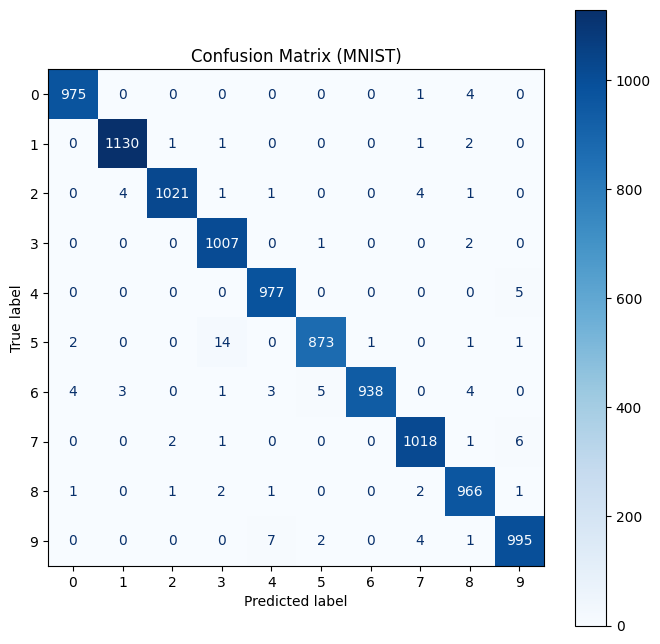

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        img_input = imgs.to(device)
        outputs = model(img_input)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix (MNIST)")


**混淆矩阵观察分析**：
混淆矩阵（Confusion Matrix）是深度学习中用于衡量分类模型性能的一种标准工具。它通过一个 $N × N$ 的方阵（其中 $N = 10$ 对应 MNIST 的 0–9 个类别）展示了模型预测结果与真实标签之间的对应关系。矩阵的行代表样本的真实类别，列代表模型给出的预测类别。
1. **对角线分布**：观察主对角线上的数值。对角线代表预测正确的样本，颜色越深、数值越大，说明模型对该特定数字的识别能力越强。可以看到，模型在识别数字 1 时的识别能力最高，而数字 5 的识别能力较弱。
2. **误判指向性**：观察非对角线上的元素。如果某个位置数值显著较高，说明模型在两个数字之间产生了特征混淆。可以看到，数字 5 易被误识别为数字 3，数字 9 易被误识别为数字 4。
3. **分类偏置分析**：观察是否存在某个数字的识别率显著低于其他数字，对比各行对角线数值。若某些数字的识别数显著低于其他数字，需结合手写体样本的笔画复杂度进行思考：模型是否在提取某些特定空间构型时失效，导致其在特定数字上的泛化性能受限。比如数字 5 易被误识别为数字 3 的原因可能是数字 5 的笔画与数字 3 的笔画相似。

## 三、简单拓展

### （一）基础调参实验
为了更好的改变参数和体现参数对结果影响，现将以上各步骤封装为一个函数。

In [6]:
def train_mnist(model, model_name, data_root, train_loader, validate_loader, optimizer,
                criterion, device, epoch_times=3):
    # 开始训练循环
    for epoch in range(epoch_times):
        print("="*15)
        print(f"第{epoch+1}个 epoch 开始训练")
        model.train()
        running_loss = 0.0
        for batch_idx, (input, labels) in enumerate(train_loader):
            input, labels = input.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(input)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            if batch_idx % 200 == 0:
                print(f"Batch {batch_idx}, Loss: {loss.item():.4f}")
        model_path = f"{model_name}_{epoch+1}.pth"
        checkpoint_dir = os.path.join(data_root, "checkpoint")
        if not os.path.exists(checkpoint_dir):
            os.makedirs(checkpoint_dir, exist_ok=True)
        save_path = os.path.join(checkpoint_dir, model_path)
        # 每个 epoch 进行一次验证
        validate_mnist(model, validate_loader, device)
        
        torch.save(model.state_dict(), save_path)
        print(f"模型权重已成功保存至数据目录 {save_path}")
    print("所有 epoch 训练完成")

def validate_mnist(model, validate_loader, device):
    model.eval()
    correct = 0
    total = 0
    print("开始验证模型...")
    with torch.no_grad():
        for inputs, labels in validate_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"验证集准确率: {100 * correct / total:.2f}%")

def test_mnist(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    print("开始测试模型...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"测试集准确率: {100 * correct / total:.2f}%")


In [9]:
def modify_epoch():
    model_1 = SimpleCNN().to(device)
    validate_loader = test_loader
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)
    train_mnist(model_1, "SimpleCNN_modify_epoch_to_5", data_root, train_loader, validate_loader, optimizer,
                criterion, device, epoch_times=5)
    test_mnist(model_1, test_loader, device)

modify_epoch()

第1个 epoch 开始训练
Batch 0, Loss: 2.3057
Batch 200, Loss: 0.2027
Batch 400, Loss: 0.2470
Batch 600, Loss: 0.1017
Batch 800, Loss: 0.0623
开始验证模型...
验证集准确率: 98.25%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\SimpleCNN_modify_epoch_to_5_1.pth
第2个 epoch 开始训练
Batch 0, Loss: 0.1495
Batch 200, Loss: 0.1009
Batch 400, Loss: 0.0951
Batch 600, Loss: 0.0623
Batch 800, Loss: 0.0135
开始验证模型...
验证集准确率: 98.85%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\SimpleCNN_modify_epoch_to_5_2.pth
第3个 epoch 开始训练
Batch 0, Loss: 0.0215
Batch 200, Loss: 0.0108
Batch 400, Loss: 0.0015
Batch 600, Loss: 0.0023
Batch 800, Loss: 0.1011
开始验证模型...
验证集准确率: 98.78%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\SimpleCNN_modify_epoch_to_5_3.pth
第4个 epoch 开始训练
Batch 0, Loss: 0.0240
Batch 200, Loss: 0.0175
Batch 400, Loss: 0.0005
Batch 600, Loss: 0.0008
Batch 800, Loss: 0.0140
开始验证模型...
验证集准确率: 98.98%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\SimpleCNN_modify_epoch_to_5_4.pth
第5个 epoch 开始训练
Batch 0, Loss: 0.0261
Batch 200, Loss: 0.0642
Batch 400, Loss

训练轮数增加后，模型性能并没有显著的提升，此时模型已经接近饱和。

In [7]:
import time


def modify_batch_size(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # 打乱样本顺序，提高训练效果
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    model_1 = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)
    train_mnist(model_1, f"SimpleCNN_modify_batch_size_to_{batch_size}", data_root, train_loader,
                test_loader, optimizer, criterion, device, epoch_times=3)
    test_mnist(model_1, test_loader, device)
    
time_start = time.time()
modify_batch_size(128)
time_end = time.time()
time_128 = time_end - time_start

time_start = time.time()
modify_batch_size(32)
time_end = time.time()
time_32 = time_end - time_start

print(f"Modify batch size to 128, time cost: {time_128:.2f}s")
print(f"Modify batch size to 32, time cost: {time_32:.2f}s")

第1个 epoch 开始训练
Batch 0, Loss: 2.2987
Batch 200, Loss: 0.0819
Batch 400, Loss: 0.1156
开始验证模型...
验证集准确率: 98.07%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\SimpleCNN_modify_batch_size_to_128_1.pth
第2个 epoch 开始训练
Batch 0, Loss: 0.0374
Batch 200, Loss: 0.0158
Batch 400, Loss: 0.0172
开始验证模型...
验证集准确率: 98.59%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\SimpleCNN_modify_batch_size_to_128_2.pth
第3个 epoch 开始训练
Batch 0, Loss: 0.0721
Batch 200, Loss: 0.0090
Batch 400, Loss: 0.0098
开始验证模型...
验证集准确率: 98.31%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\SimpleCNN_modify_batch_size_to_128_3.pth
所有 epoch 训练完成
开始测试模型...
测试集准确率: 98.31%
第1个 epoch 开始训练
Batch 0, Loss: 2.3298
Batch 200, Loss: 0.2343
Batch 400, Loss: 0.0536
Batch 600, Loss: 0.1275
Batch 800, Loss: 0.0483
Batch 1000, Loss: 0.0247
Batch 1200, Loss: 0.0430
Batch 1400, Loss: 0.1536
Batch 1600, Loss: 0.0811
Batch 1800, Loss: 0.0675
开始验证模型...
验证集准确率: 98.25%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\SimpleCNN_modify_batch_size_to_32_1.pth
第2个 epoch 开始训练
Batch 0, Loss:

当批量大小为128时，训练时间变短，为39.02s；当批量大小为32时，训练时间变长，为59.85s。
批量大小越大，训练时间越短，反之，训练时间越长。

### （二）加入 Dropout 层

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DropoutCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = self.dropout(x)  # 在全连接层前添加dropout层
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dropout = DropoutCNN().to(device)
print(model_dropout)

DropoutCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
def test_dropout():
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)  # 打乱样本顺序，提高训练效果
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    model_dropout = DropoutCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_dropout.parameters(), lr=0.001)
    train_mnist(model_dropout, f"DropoutCNN", data_root, train_loader,
                test_loader, optimizer, criterion, device, epoch_times=3)
    test_mnist(model_dropout, test_loader, device)

In [11]:
test_dropout()

第1个 epoch 开始训练
Batch 0, Loss: 2.3104
Batch 200, Loss: 0.1837
Batch 400, Loss: 0.0957
Batch 600, Loss: 0.1002
Batch 800, Loss: 0.1036
开始验证模型...
验证集准确率: 98.00%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\DropoutCNN_modify_batch_size_to_64_1.pth
第2个 epoch 开始训练
Batch 0, Loss: 0.0429
Batch 200, Loss: 0.0351
Batch 400, Loss: 0.0247
Batch 600, Loss: 0.0149
Batch 800, Loss: 0.0135
开始验证模型...
验证集准确率: 98.93%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\DropoutCNN_modify_batch_size_to_64_2.pth
第3个 epoch 开始训练
Batch 0, Loss: 0.0089
Batch 200, Loss: 0.0646
Batch 400, Loss: 0.0153
Batch 600, Loss: 0.0363
Batch 800, Loss: 0.1677
开始验证模型...
验证集准确率: 98.84%
模型权重已成功保存至数据目录 ./mnist_data/checkpoint\DropoutCNN_modify_batch_size_to_64_3.pth
所有 epoch 训练完成
开始测试模型...
测试集准确率: 98.84%


**加入 Dropout 相较未加 Dropout**：

**模型的最终准确率几乎不变**：因为当前训练的程度已经足够好，再加入 Dropout 也不会显著提高模型的准确率。

**模型 Loss 下降变缓慢**：失活部分神经元后，模型的拟合能力会下降，导致 Loss 下降变缓慢，但可以提高模型的泛化能力。

## 四、心得体会
本次实验学习了 Pytorch环境下卷积神经网络的搭建和训练，以及在 MNIST 数据集上的应用，尝试了不同参数配置和模型结构对模型性能的影响。
